In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# =========================================================
# Simple cross-validation scheme
# =========================================================

# Step 1: Generate synthetic data for classification
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_classes=2,
    random_state=42
)


In [2]:
# Step 2: Cross-validation setup
c_value = 0.001
n_folds = 5
cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

accuracies = []


In [3]:
# Step 3: Perform simple cross-validation
for train_index, test_index in cv.split(X, y):
    # Split
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Training
    clf = LogisticRegression(C=c_value, max_iter=1000, solver='liblinear')
    clf.fit(X_train, y_train)

    # Prediction and results
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

print(f"Average Accuracy (Fixed C = {c_value}): {np.mean(accuracies):.3f}")

# =========================================================
# Nested cross-validation scheme
# =========================================================

Average Accuracy (Fixed C = 0.001): 0.865


In [4]:
# Step 4: Nested CV setup
parameters_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

inner_cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

outer_accuracies = []
best_cs = []


In [5]:
# Step 5: Perform nested cross-validation
for train_index, test_index in outer_cv.split(X, y):
    # Outer split
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    inner_accuracies = []

    # Try each C value in the inner loop
    for c_value in parameters_grid['C']:
        inner_folds = []

        for inner_train_index, inner_val_index in inner_cv.split(X_train, y_train):
            # Inner split
            X_train_fold = X_train[inner_train_index]
            X_val_fold = X_train[inner_val_index]
            y_train_fold = y_train[inner_train_index]
            y_val_fold = y_train[inner_val_index]

            # Inner training
            clf = LogisticRegression(C=c_value, max_iter=1000, solver='liblinear')
            clf.fit(X_train_fold, y_train_fold)

            # Inner prediction and results
            y_pred = clf.predict(X_val_fold)
            inner_score = accuracy_score(y_val_fold, y_pred)
            inner_folds.append(inner_score)

        # Mean inner accuracy for this C
        mean_score = np.mean(inner_folds)
        inner_accuracies.append(mean_score)

    # Best C from inner CV
    best_c = parameters_grid['C'][np.argmax(inner_accuracies)]
    best_cs.append(best_c)

    # Train model with best C on the full outer training set
    clf = LogisticRegression(C=best_c, max_iter=1000, solver='liblinear')
    clf.fit(X_train, y_train)

    # Test on outer fold
    y_pred = clf.predict(X_test)
    outer_accuracy = accuracy_score(y_test, y_pred)
    outer_accuracies.append(outer_accuracy)

print(f"Best C values selected in outer folds: {best_cs}")
print(f"Average Accuracy (Nested CV): {np.mean(outer_accuracies):.3f}")

Best C values selected in outer folds: [0.01, 0.1, 0.001, 0.01, 0.1]
Average Accuracy (Nested CV): 0.859


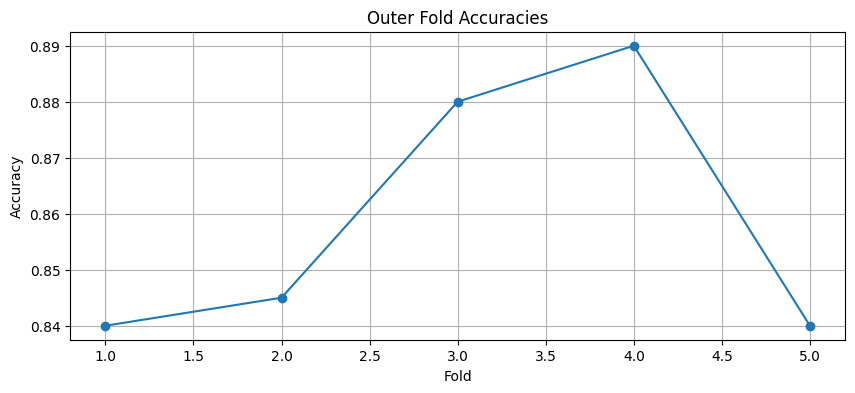

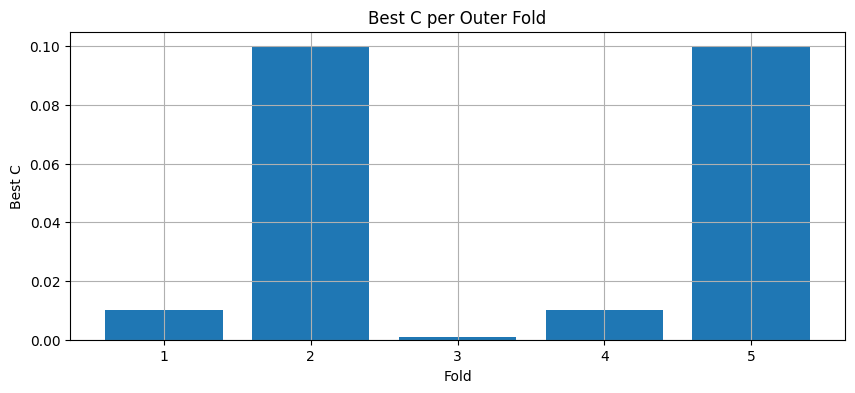

In [6]:
# =========================================================
# Step 6: Plotting
# =========================================================

plt.figure(figsize=(10, 4))
plt.plot(range(1, n_folds + 1), outer_accuracies, marker='o')
plt.title('Outer Fold Accuracies')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(range(1, n_folds + 1), best_cs)
plt.title('Best C per Outer Fold')
plt.xlabel('Fold')
plt.ylabel('Best C')
plt.grid(True)
plt.show()

In [7]:
# =========================================================
# Step 7: Comparison between accuracies
# =========================================================

fixed_accuracy = np.mean(accuracies)
nested_accuracy = np.mean(outer_accuracies)
accuracy_difference = abs(nested_accuracy - fixed_accuracy)

print(f"Accuracy (Fixed C = 0.001): {fixed_accuracy:.3f}")
print(f"Accuracy (Nested CV best C): {nested_accuracy:.3f}")
print(f"Difference: {accuracy_difference:.3f}")

Accuracy (Fixed C = 0.001): 0.865
Accuracy (Nested CV best C): 0.859
Difference: 0.006
